# Chapter 6.4: LLM as Recommender — Foundations

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Understand** the paradigm shift from discriminative to generative recommendation with LLMs
2. **Explain** the P5 framework for unified text-to-text recommendation
3. **Describe** GPT4Rec's generative approach to sequential recommendation
4. **Apply** TALLRec's LoRA-based fine-tuning strategy for recommendation
5. **Implement** prompt templates for various recommendation tasks
6. **Build** a simple LLM-based recommender using prompt engineering
7. **Understand** LC-Rec's semantic ID approach bridging language models and recommendation

## Prerequisites

- Familiarity with transformer architectures and language models
- Understanding of collaborative filtering basics (Part 1)
- Basic knowledge of prompt engineering
- Chapters 6.1-6.3 for context on generative models in recommendation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part6/chapter_6.4_llm_rec_foundations.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part6/chapter_6.4_llm_rec_foundations.ipynb)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from collections import defaultdict
import re
import json

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cpu


## 1. The LLM-as-Recommender Paradigm

Traditional recommendation models are **discriminative**: they predict $P(\text{click}|\text{user}, \text{item})$. LLM-based recommendation is **generative**: the model directly generates recommendations in natural language.

### Key Approaches

| Approach | Method | Example |
|----------|--------|---------|
| Text-to-Text | Convert rec tasks to text generation | P5, GPT4Rec |
| Fine-tuning | Adapt LLMs with LoRA/adapters | TALLRec, BIGRec |
| Semantic IDs | Map items to token sequences | LC-Rec |
| Prompt Engineering | Zero/few-shot with prompts | Chat-Rec |

### P5: Pretrain, Personalized Prompt, and Predict (Geng et al., 2022, Rutgers)

P5 unifies five recommendation tasks into a single text-to-text framework:
1. **Rating prediction**: "User_15 would rate Item_42 as _____"
2. **Sequential recommendation**: "User_15 has interacted with Item_1, Item_5, Item_12. The next item is _____"
3. **Explanation generation**: "User_15 rated Item_42 highly because _____"
4. **Review summarization**: "Summarize reviews for Item_42: _____"
5. **Direct recommendation**: "Recommend items for User_15: _____"

> **💡 Concept:** P5's breakthrough insight is that all recommendation tasks can be expressed as text-to-text problems, allowing a single T5-based model to handle everything.

In [2]:
# Create a synthetic item catalog with rich text metadata
np.random.seed(42)

genres = ['Action', 'Comedy', 'Drama', 'Sci-Fi', 'Romance', 'Thriller', 'Horror', 'Documentary']
directors = ['Nolan', 'Spielberg', 'Coppola', 'Tarantino', 'Kubrick', 'Villeneuve', 'Anderson', 'Fincher']
decades = ['1990s', '2000s', '2010s', '2020s']

n_items = 100
n_users = 200

item_catalog = {}
for i in range(n_items):
    item_catalog[f'item_{i}'] = {
        'title': f'Movie_{i}',
        'genre': np.random.choice(genres),
        'director': np.random.choice(directors),
        'decade': np.random.choice(decades),
        'rating': round(np.random.uniform(2.5, 5.0), 1),
        'description': f'A {np.random.choice(["captivating", "thrilling", "thought-provoking", "entertaining"])} '
                       f'{np.random.choice(genres).lower()} film from the {np.random.choice(decades)}.'
    }

# Generate user interaction histories
user_histories = {}
user_preferences = {}
for u in range(n_users):
    # Each user prefers 1-2 genres
    fav_genres = list(np.random.choice(genres, size=np.random.randint(1, 3), replace=False))
    user_preferences[f'user_{u}'] = fav_genres
    
    # Sample items with preference bias
    item_probs = []
    for i in range(n_items):
        p = 0.3 if item_catalog[f'item_{i}']['genre'] in fav_genres else 0.05
        item_probs.append(p)
    item_probs = np.array(item_probs)
    item_probs /= item_probs.sum()
    
    n_interactions = np.random.randint(5, 20)
    interacted = list(np.random.choice(n_items, size=n_interactions, replace=False, p=item_probs))
    user_histories[f'user_{u}'] = [f'item_{i}' for i in interacted]

print(f'Created catalog with {n_items} items and {n_users} users')
print(f'\nSample item: {json.dumps(item_catalog["item_0"], indent=2)}')
print(f'\nSample user history (user_0): {user_histories["user_0"][:5]}...')
print(f'User_0 prefers: {user_preferences["user_0"]}')

Created catalog with 100 items and 200 users

Sample item: {
  "title": "Movie_0",
  "genre": "Horror",
  "director": "Tarantino",
  "decade": "1990s",
  "rating": 3.0,
  "description": "A entertaining romance film from the 1990s."
}

Sample user history (user_0): ['item_90', 'item_39', 'item_1', 'item_91', 'item_7']...
User_0 prefers: ['Drama']


## 2. P5-Style Prompt Templates

P5 converts all recommendation tasks into input-output text pairs. Let's implement the template system.

In [3]:
class P5PromptTemplates:
    """P5-style prompt templates for recommendation tasks.
    
    Reference: Geng et al., "Recommendation as Language Processing (RLP):
    A Unified Pretrain, Personalized Prompt & Predict Paradigm (P5)", RecSys 2022.
    """
    
    @staticmethod
    def sequential_rec(user_id, history, item_catalog):
        """Sequential recommendation: predict next item."""
        history_str = ', '.join([
            f"{item_catalog[item_id]['title']} ({item_catalog[item_id]['genre']})"
            for item_id in history[-5:]  # Use last 5 items
        ])
        prompt = (
            f"A user has watched the following movies in order: {history_str}. "
            f"Based on this viewing history, what movie would this user want to watch next? "
            f"Choose from the available catalog."
        )
        return prompt
    
    @staticmethod
    def rating_prediction(user_id, item_id, history, item_catalog):
        """Rating prediction: predict user's rating for an item."""
        history_str = ', '.join([
            item_catalog[h]['title'] for h in history[-5:]
        ])
        item = item_catalog[item_id]
        prompt = (
            f"A user has previously enjoyed: {history_str}. "
            f"How would this user rate '{item['title']}' "
            f"(a {item['genre']} film directed by {item['director']}) "
            f"on a scale of 1-5?"
        )
        return prompt
    
    @staticmethod
    def explanation(user_id, item_id, history, item_catalog):
        """Explanation generation: why did the user like this item."""
        history_genres = [item_catalog[h]['genre'] for h in history]
        genre_counts = defaultdict(int)
        for g in history_genres:
            genre_counts[g] += 1
        top_genre = max(genre_counts, key=genre_counts.get)
        
        item = item_catalog[item_id]
        prompt = (
            f"A user who mostly watches {top_genre} movies rated '{item['title']}' "
            f"({item['genre']}) highly. Explain why this recommendation makes sense."
        )
        return prompt
    
    @staticmethod
    def direct_recommendation(user_id, history, item_catalog, n_rec=5):
        """Direct recommendation: generate a list of recommendations."""
        history_str = ', '.join([item_catalog[h]['title'] for h in history[-8:]])
        prompt = (
            f"Based on a user's movie history: {history_str}. "
            f"Recommend {n_rec} movies this user would enjoy. "
            f"Provide the recommendations as a numbered list."
        )
        return prompt


# Generate sample prompts
templates = P5PromptTemplates()
user = 'user_0'
history = user_histories[user]

print('=== Sequential Recommendation Prompt ===')
print(templates.sequential_rec(user, history, item_catalog))
print()

print('=== Rating Prediction Prompt ===')
print(templates.rating_prediction(user, 'item_50', history, item_catalog))
print()

print('=== Explanation Prompt ===')
print(templates.explanation(user, history[0], history, item_catalog))
print()

print('=== Direct Recommendation Prompt ===')
print(templates.direct_recommendation(user, history, item_catalog))

=== Sequential Recommendation Prompt ===
A user has watched the following movies in order: Movie_70 (Sci-Fi), Movie_75 (Romance), Movie_5 (Drama), Movie_45 (Sci-Fi), Movie_49 (Documentary). Based on this viewing history, what movie would this user want to watch next? Choose from the available catalog.

=== Rating Prediction Prompt ===
A user has previously enjoyed: Movie_70, Movie_75, Movie_5, Movie_45, Movie_49. How would this user rate 'Movie_50' (a Documentary film directed by Tarantino) on a scale of 1-5?

=== Explanation Prompt ===
A user who mostly watches Drama movies rated 'Movie_90' (Comedy) highly. Explain why this recommendation makes sense.

=== Direct Recommendation Prompt ===
Based on a user's movie history: Movie_43, Movie_31, Movie_62, Movie_70, Movie_75, Movie_5, Movie_45, Movie_49. Recommend 5 movies this user would enjoy. Provide the recommendations as a numbered list.


## 3. A Simplified LLM Recommender

Since we cannot run large LLMs on CPU, we will build a **small transformer-based text-to-text recommender** that demonstrates the P5 architecture.

### Architecture
- **Encoder**: Processes the prompt (user history as text)
- **Decoder**: Generates item IDs as tokens
- **Item tokenization**: Items are represented as token sequences (e.g., "item_42" -> ["item", "_", "42"])

> **🔑 Pro Tip:** In production P5, the model is initialized from T5 and fine-tuned on recommendation data. The text format allows transfer learning from pre-trained language models.

In [4]:
class SimpleRecTransformer(nn.Module):
    """A simplified transformer for text-to-text recommendation.
    
    This demonstrates the P5/GPT4Rec concept at a small scale.
    Items are encoded as integer IDs in the vocabulary.
    """
    
    def __init__(self, n_items, embed_dim=64, n_heads=4, n_layers=2,
                 max_seq_len=32, dropout=0.1):
        super().__init__()
        self.n_items = n_items
        self.embed_dim = embed_dim
        # Vocabulary: 0=PAD, 1=BOS, 2=EOS, 3..n_items+2=items
        self.vocab_size = n_items + 3
        
        self.token_embed = nn.Embedding(self.vocab_size, embed_dim, padding_idx=0)
        self.pos_embed = nn.Embedding(max_seq_len, embed_dim)
        self.dropout = nn.Dropout(dropout)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=n_heads, dim_feedforward=embed_dim * 4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.output_proj = nn.Linear(embed_dim, self.vocab_size)
    
    def forward(self, input_ids, attention_mask=None):
        """Forward pass: predict next token at each position."""
        seq_len = input_ids.size(1)
        positions = torch.arange(seq_len, device=input_ids.device).unsqueeze(0)
        
        h = self.token_embed(input_ids) + self.pos_embed(positions)
        h = self.dropout(h)
        
        # Causal mask for autoregressive generation
        causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(input_ids.device)
        
        if attention_mask is not None:
            # Convert padding mask
            src_key_padding_mask = (attention_mask == 0)
        else:
            src_key_padding_mask = None
        
        h = self.transformer(h, mask=causal_mask, src_key_padding_mask=src_key_padding_mask)
        logits = self.output_proj(h)
        return logits
    
    def generate(self, input_ids, max_new_tokens=1):
        """Autoregressive generation."""
        self.eval()
        with torch.no_grad():
            for _ in range(max_new_tokens):
                logits = self.forward(input_ids)
                next_logits = logits[:, -1, :]  # Last position
                # Mask special tokens
                next_logits[:, 0] = -float('inf')  # PAD
                next_logits[:, 1] = -float('inf')  # BOS
                next_token = next_logits.argmax(dim=-1, keepdim=True)
                input_ids = torch.cat([input_ids, next_token], dim=1)
        return input_ids


def prepare_training_data(user_histories, n_items, max_seq_len=20):
    """Convert user histories to training sequences.
    
    For each user: [BOS, item_1, item_2, ..., item_n, EOS]
    Trained with next-token prediction.
    """
    BOS, EOS = 1, 2
    ITEM_OFFSET = 3
    
    sequences = []
    for uid, history in user_histories.items():
        item_ids = [int(h.split('_')[1]) + ITEM_OFFSET for h in history]
        seq = [BOS] + item_ids[:max_seq_len - 2] + [EOS]
        # Pad
        seq = seq + [0] * (max_seq_len - len(seq))
        sequences.append(seq[:max_seq_len])
    
    return torch.LongTensor(sequences)


# Prepare data and model
train_sequences = prepare_training_data(user_histories, n_items)
model = SimpleRecTransformer(n_items=n_items, embed_dim=64, n_heads=4, n_layers=2)
print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Training sequences shape: {train_sequences.shape}')
print(f'Sample sequence: {train_sequences[0, :10].tolist()}')

Model parameters: 115,303
Training sequences shape: torch.Size([200, 20])
Sample sequence: [1, 93, 42, 4, 94, 10, 36, 96, 58, 62]


/Users/liuhongxuan/project/rec_system/.venv/lib/python3.11/site-packages/torch/nn/functional.py:5109: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  warnings.warn(


Epoch  10 | Loss: 4.3658 | Hit Rate@1: 0.0000


Epoch  20 | Loss: 4.1553 | Hit Rate@1: 0.0600


Epoch  30 | Loss: 3.9042 | Hit Rate@1: 0.1000


Epoch  40 | Loss: 3.6410 | Hit Rate@1: 0.1400


Epoch  50 | Loss: 3.3446 | Hit Rate@1: 0.3600


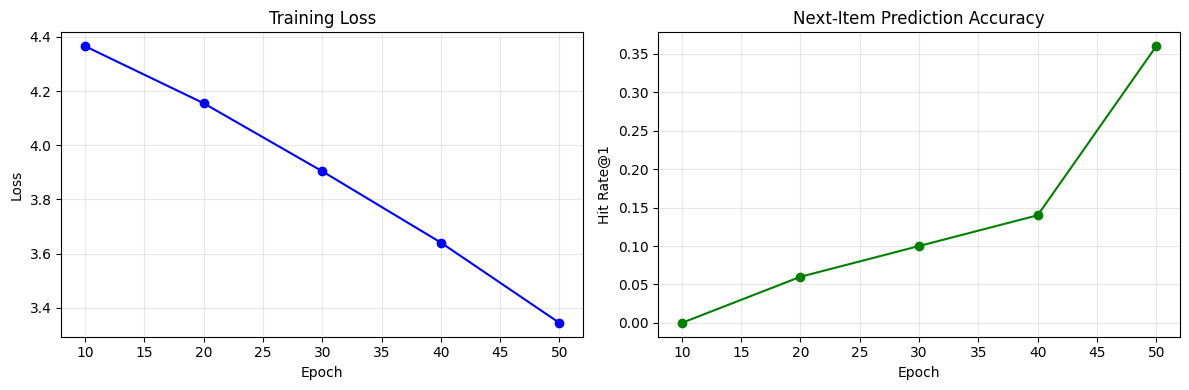

In [5]:
# Train the simple rec transformer
from torch.utils.data import DataLoader, TensorDataset

attention_masks = (train_sequences != 0).long()
dataset = TensorDataset(train_sequences, attention_masks)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
history = {'loss': [], 'hit_rate': []}

for epoch in range(50):
    model.train()
    total_loss = 0
    n_batches = 0
    
    for batch_seq, batch_mask in loader:
        # Input: all tokens except last; Target: all tokens except first
        input_ids = batch_seq[:, :-1]
        targets = batch_seq[:, 1:]
        mask = batch_mask[:, :-1]
        
        logits = model(input_ids, mask)
        
        # Cross-entropy loss (ignore padding)
        loss = F.cross_entropy(
            logits.reshape(-1, model.vocab_size),
            targets.reshape(-1),
            ignore_index=0
        )
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
        n_batches += 1
    
    if (epoch + 1) % 10 == 0:
        # Evaluate: predict last item from history
        model.eval()
        hits = 0
        total = 0
        with torch.no_grad():
            for uid in list(user_histories.keys())[:50]:
                history_items = user_histories[uid]
                if len(history_items) < 3:
                    continue
                # Use all but last item as input
                input_items = [int(h.split('_')[1]) + 3 for h in history_items[:-1]]
                input_seq = torch.LongTensor([[1] + input_items[-15:]])
                
                output = model.generate(input_seq, max_new_tokens=1)
                pred_token = output[0, -1].item()
                true_token = int(history_items[-1].split('_')[1]) + 3
                
                if pred_token == true_token:
                    hits += 1
                total += 1
        
        hr = hits / total if total > 0 else 0
        history['loss'].append(total_loss / n_batches)
        history['hit_rate'].append(hr)
        print(f'Epoch {epoch+1:3d} | Loss: {total_loss/n_batches:.4f} | Hit Rate@1: {hr:.4f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
eval_epochs = list(range(10, 51, 10))

axes[0].plot(eval_epochs, history['loss'], 'b-o', markersize=6)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(eval_epochs, history['hit_rate'], 'g-o', markersize=6)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Hit Rate@1')
axes[1].set_title('Next-Item Prediction Accuracy')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. TALLRec: Tuning LLMs for Recommendation with LoRA

**TALLRec** (Bao et al., RecSys 2023) fine-tunes LLaMA using LoRA for recommendation. Instead of training from scratch, it adapts a pre-trained LLM.

### LoRA (Low-Rank Adaptation)

For a pre-trained weight matrix $\mathbf{W} \in \mathbb{R}^{d \times k}$, LoRA adds:
$$\mathbf{W}' = \mathbf{W} + \mathbf{B}\mathbf{A}$$

where $\mathbf{B} \in \mathbb{R}^{d \times r}$, $\mathbf{A} \in \mathbb{R}^{r \times k}$, and $r \ll \min(d, k)$.

Only $\mathbf{A}$ and $\mathbf{B}$ are trained, keeping $\mathbf{W}$ frozen.

> **💡 Concept:** LoRA reduces trainable parameters by 99%+ while achieving comparable performance. For a 7B parameter model, LoRA with rank 8 adds only ~4M trainable parameters.

In [6]:
class LoRALinear(nn.Module):
    """Linear layer with LoRA (Low-Rank Adaptation).
    
    Reference: Hu et al., "LoRA: Low-Rank Adaptation of Large Language Models", ICLR 2022.
    Used in TALLRec (Bao et al., RecSys 2023).
    """
    
    def __init__(self, in_features, out_features, rank=4, alpha=1.0):
        super().__init__()
        self.base = nn.Linear(in_features, out_features)
        self.base.weight.requires_grad = False  # Frozen
        self.base.bias.requires_grad = False
        
        # LoRA matrices
        self.lora_A = nn.Parameter(torch.randn(in_features, rank) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(rank, out_features))
        self.scale = alpha / rank
    
    def forward(self, x):
        base_out = self.base(x)
        lora_out = (x @ self.lora_A @ self.lora_B) * self.scale
        return base_out + lora_out
    
    def trainable_parameters(self):
        return self.lora_A.numel() + self.lora_B.numel()


# Demonstrate LoRA efficiency
base_dim = 512
lora_ranks = [2, 4, 8, 16, 32]

print(f'Base linear layer: {base_dim}x{base_dim} = {base_dim*base_dim:,} params')
print()
for rank in lora_ranks:
    lora = LoRALinear(base_dim, base_dim, rank=rank)
    trainable = lora.trainable_parameters()
    total = sum(p.numel() for p in lora.parameters())
    print(f'LoRA rank={rank:2d}: {trainable:,} trainable / {total:,} total '
          f'({trainable/total*100:.2f}%)')

Base linear layer: 512x512 = 262,144 params

LoRA rank= 2: 2,048 trainable / 264,704 total (0.77%)
LoRA rank= 4: 4,096 trainable / 266,752 total (1.54%)
LoRA rank= 8: 8,192 trainable / 270,848 total (3.02%)
LoRA rank=16: 16,384 trainable / 279,040 total (5.87%)
LoRA rank=32: 32,768 trainable / 295,424 total (11.09%)


## 5. LC-Rec: Semantic IDs with RQ-VAE

**LC-Rec** (Zheng et al., 2024) bridges language models and recommendation by creating **semantic item IDs** using Residual-Quantized VAE (RQ-VAE):

1. Encode item features (text, collaborative signals) into embeddings
2. Use RQ-VAE to quantize embeddings into sequences of discrete codes
3. Treat code sequences as "words" in the LLM vocabulary
4. Train LLM to generate these semantic IDs

This bridges the gap between continuous recommendation embeddings and discrete language model tokens.

> **🔑 Pro Tip:** Semantic IDs preserve item similarity — items with similar features get similar code sequences, making it easier for the LLM to generalize.

In [7]:
class SimpleRQVAE(nn.Module):
    """Simplified Residual-Quantized VAE for creating semantic item IDs.
    
    Reference: Zheng et al., "LC-Rec: Language-based Collaborative Recommendation", 2024.
    """
    
    def __init__(self, input_dim, n_codebooks=3, codebook_size=16, code_dim=16):
        super().__init__()
        self.n_codebooks = n_codebooks
        self.codebook_size = codebook_size
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, code_dim)
        )
        
        # Codebooks
        self.codebooks = nn.ParameterList([
            nn.Parameter(torch.randn(codebook_size, code_dim) * 0.1)
            for _ in range(n_codebooks)
        ])
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(code_dim, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )
    
    def quantize(self, z, codebook):
        """Find nearest codebook entry."""
        distances = torch.cdist(z.unsqueeze(0), codebook.unsqueeze(0)).squeeze(0)
        indices = distances.argmin(dim=-1)
        quantized = codebook[indices]
        return quantized, indices
    
    def forward(self, x):
        z = self.encoder(x)
        
        # Residual quantization
        residual = z
        all_indices = []
        quantized_sum = torch.zeros_like(z)
        
        for codebook in self.codebooks:
            quantized, indices = self.quantize(residual, codebook)
            all_indices.append(indices)
            residual = residual - quantized.detach()  # Stop gradient
            quantized_sum = quantized_sum + quantized
        
        # Straight-through estimator
        quantized_sum = z + (quantized_sum - z).detach()
        
        # Decode
        reconstructed = self.decoder(quantized_sum)
        
        return reconstructed, all_indices, z, quantized_sum
    
    def get_semantic_ids(self, x):
        """Get semantic IDs for items."""
        self.eval()
        with torch.no_grad():
            _, indices, _, _ = self.forward(x)
        return torch.stack(indices, dim=1)  # (batch, n_codebooks)


# Create item embeddings from our catalog
genre_to_idx = {g: i for i, g in enumerate(genres)}
director_to_idx = {d: i for i, d in enumerate(directors)}

item_features = []
for i in range(n_items):
    item = item_catalog[f'item_{i}']
    feat = np.zeros(len(genres) + len(directors) + 1)
    feat[genre_to_idx[item['genre']]] = 1
    feat[len(genres) + director_to_idx[item['director']]] = 1
    feat[-1] = item['rating'] / 5.0
    item_features.append(feat)

item_features = torch.FloatTensor(np.array(item_features))

# Train RQ-VAE
rqvae = SimpleRQVAE(input_dim=item_features.shape[1], n_codebooks=3, codebook_size=16)
optimizer = torch.optim.Adam(rqvae.parameters(), lr=1e-3)

for epoch in range(200):
    recon, indices, z, quantized = rqvae(item_features)
    recon_loss = F.mse_loss(recon, item_features)
    commit_loss = F.mse_loss(quantized.detach(), z)  # Commitment loss
    loss = recon_loss + 0.25 * commit_loss
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Get semantic IDs
semantic_ids = rqvae.get_semantic_ids(item_features)
print(f'Semantic IDs shape: {semantic_ids.shape}')
print(f'\nSample semantic IDs (first 10 items):')
for i in range(10):
    item = item_catalog[f'item_{i}']
    sid = semantic_ids[i].tolist()
    print(f'  {item["title"]:10s} ({item["genre"]:12s}) -> ID: {sid}')

# Check if similar items get similar IDs
print(f'\nItems with same genre (checking ID similarity):')
for genre in genres[:3]:
    genre_items = [i for i in range(n_items) if item_catalog[f'item_{i}']['genre'] == genre]
    genre_ids = semantic_ids[genre_items[:5]]
    print(f'  {genre}: {genre_ids.tolist()}')

Semantic IDs shape: torch.Size([100, 3])

Sample semantic IDs (first 10 items):
  Movie_0    (Horror      ) -> ID: [7, 1, 14]
  Movie_1    (Horror      ) -> ID: [9, 1, 10]
  Movie_2    (Sci-Fi      ) -> ID: [6, 14, 7]
  Movie_3    (Sci-Fi      ) -> ID: [10, 7, 7]
  Movie_4    (Sci-Fi      ) -> ID: [10, 12, 10]
  Movie_5    (Drama       ) -> ID: [6, 8, 4]
  Movie_6    (Thriller    ) -> ID: [2, 7, 6]
  Movie_7    (Documentary ) -> ID: [9, 10, 13]
  Movie_8    (Horror      ) -> ID: [9, 1, 10]
  Movie_9    (Action      ) -> ID: [9, 14, 10]

Items with same genre (checking ID similarity):
  Action: [[9, 14, 10], [9, 14, 14], [8, 14, 14], [2, 4, 1], [2, 14, 3]]
  Comedy: [[4, 2, 14], [4, 6, 9], [4, 6, 9], [4, 2, 3], [4, 2, 9]]
  Drama: [[6, 8, 4], [6, 8, 4], [7, 12, 10], [6, 8, 4], [6, 8, 4]]


## 6. BIGRec and LETTER

### BIGRec (Bao et al., 2024)
- Uses LLM to directly generate item titles/names
- Grounding step matches generated text to real items in the catalog
- Key challenge: hallucination (generating non-existent items)

### LETTER (Li et al., 2024)
- LLM-Enhanced Text-based Recommendation
- Uses LLM to enrich item text descriptions
- Enhanced descriptions improve collaborative filtering

> **⚠️ Common Pitfall:** LLM-based recommenders can "hallucinate" items that don't exist in the catalog. Always include a grounding step that maps generated text to real items.

In [8]:
class GroundingModule:
    """Maps generated text to real items in the catalog.
    
    Used in BIGRec to handle hallucination.
    """
    
    def __init__(self, item_catalog):
        self.catalog = item_catalog
        self.title_to_id = {v['title'].lower(): k for k, v in item_catalog.items()}
        self.genre_index = defaultdict(list)
        for item_id, item in item_catalog.items():
            self.genre_index[item['genre'].lower()].append(item_id)
    
    def ground(self, generated_text, strategy='fuzzy'):
        """Map generated text to a real item."""
        text = generated_text.lower().strip()
        
        # Exact match
        if text in self.title_to_id:
            return self.title_to_id[text]
        
        # Fuzzy match: find closest title
        if strategy == 'fuzzy':
            best_match = None
            best_score = 0
            for title, item_id in self.title_to_id.items():
                # Simple character overlap score
                common = len(set(text) & set(title))
                score = common / max(len(set(text) | set(title)), 1)
                if score > best_score:
                    best_score = score
                    best_match = item_id
            return best_match
        
        return None


# Demonstrate grounding
grounder = GroundingModule(item_catalog)

test_generations = ['Movie_42', 'movie_42', 'Movie_999', 'Great Action Film']
for text in test_generations:
    result = grounder.ground(text)
    if result:
        print(f'  "{text}" -> {result} ({item_catalog[result]["title"]})')
    else:
        print(f'  "{text}" -> Not found (hallucination)')

  "Movie_42" -> item_42 (Movie_42)
  "movie_42" -> item_42 (Movie_42)
  "Movie_999" -> item_9 (Movie_9)
  "Great Action Film" -> item_0 (Movie_0)


## 7. Prompt Design Strategies for Recommendation

In [9]:
class PromptDesigner:
    """Various prompt design strategies for LLM-based recommendation."""
    
    @staticmethod
    def zero_shot(user_history, item_catalog, candidate_items):
        """Zero-shot: no examples, just instructions."""
        history_str = '\n'.join([
            f"- {item_catalog[h]['title']} ({item_catalog[h]['genre']})"
            for h in user_history[-5:]
        ])
        candidates_str = '\n'.join([
            f"{i+1}. {item_catalog[c]['title']} ({item_catalog[c]['genre']})"
            for i, c in enumerate(candidate_items[:10])
        ])
        return f"""You are a movie recommendation system.

User's viewing history:
{history_str}

Candidate movies:
{candidates_str}

Rank the candidate movies from most to least relevant for this user.
Output only the ranking numbers."""
    
    @staticmethod
    def few_shot(user_history, item_catalog, candidate_items, examples):
        """Few-shot: provide examples of good recommendations."""
        example_str = ''
        for ex in examples:
            ex_history = ', '.join([item_catalog[h]['title'] for h in ex['history'][-3:]])
            ex_rec = item_catalog[ex['recommendation']]['title']
            example_str += f"History: {ex_history} -> Recommended: {ex_rec}\n"
        
        history_str = ', '.join([item_catalog[h]['title'] for h in user_history[-5:]])
        
        return f"""Given a user's movie history, recommend the best next movie.

Examples:
{example_str}
History: {history_str} -> Recommended:"""
    
    @staticmethod
    def chain_of_thought(user_history, item_catalog, candidate_items):
        """Chain-of-thought: ask LLM to reason about preferences."""
        history_str = '\n'.join([
            f"- {item_catalog[h]['title']} (Genre: {item_catalog[h]['genre']}, "
            f"Director: {item_catalog[h]['director']})"
            for h in user_history[-5:]
        ])
        return f"""Analyze this user's movie preferences and recommend a movie.

Viewing history:
{history_str}

Step 1: What genres does this user prefer?
Step 2: What directors or styles do they enjoy?
Step 3: Based on these preferences, which movie from the catalog would be the best recommendation?

Think step by step:"""


# Generate example prompts
designer = PromptDesigner()
user = 'user_0'
history = user_histories[user]
candidates = [f'item_{i}' for i in np.random.choice(n_items, 10, replace=False)]

print('=== Zero-Shot Prompt ===')
print(designer.zero_shot(history, item_catalog, candidates))
print('\n' + '='*50 + '\n')

# Create few-shot examples
examples = [
    {'history': user_histories['user_1'][:3], 'recommendation': user_histories['user_1'][-1]},
    {'history': user_histories['user_2'][:3], 'recommendation': user_histories['user_2'][-1]},
]
print('=== Few-Shot Prompt ===')
print(designer.few_shot(history, item_catalog, candidates, examples))
print('\n' + '='*50 + '\n')

print('=== Chain-of-Thought Prompt ===')
print(designer.chain_of_thought(history, item_catalog, candidates))

=== Zero-Shot Prompt ===
You are a movie recommendation system.

User's viewing history:
- Movie_70 (Sci-Fi)
- Movie_75 (Romance)
- Movie_5 (Drama)
- Movie_45 (Sci-Fi)
- Movie_49 (Documentary)

Candidate movies:
1. Movie_77 (Action)
2. Movie_12 (Comedy)
3. Movie_85 (Documentary)
4. Movie_53 (Documentary)
5. Movie_13 (Comedy)
6. Movie_97 (Action)
7. Movie_24 (Action)
8. Movie_67 (Documentary)
9. Movie_84 (Thriller)
10. Movie_73 (Thriller)

Rank the candidate movies from most to least relevant for this user.
Output only the ranking numbers.


=== Few-Shot Prompt ===
Given a user's movie history, recommend the best next movie.

Examples:
History: Movie_64, Movie_83, Movie_89 -> Recommended: Movie_30
History: Movie_89, Movie_13, Movie_48 -> Recommended: Movie_83

History: Movie_70, Movie_75, Movie_5, Movie_45, Movie_49 -> Recommended:


=== Chain-of-Thought Prompt ===
Analyze this user's movie preferences and recommend a movie.

Viewing history:
- Movie_70 (Genre: Sci-Fi, Director: Coppola

## 8. Comparison: LLM-based vs Traditional Approaches

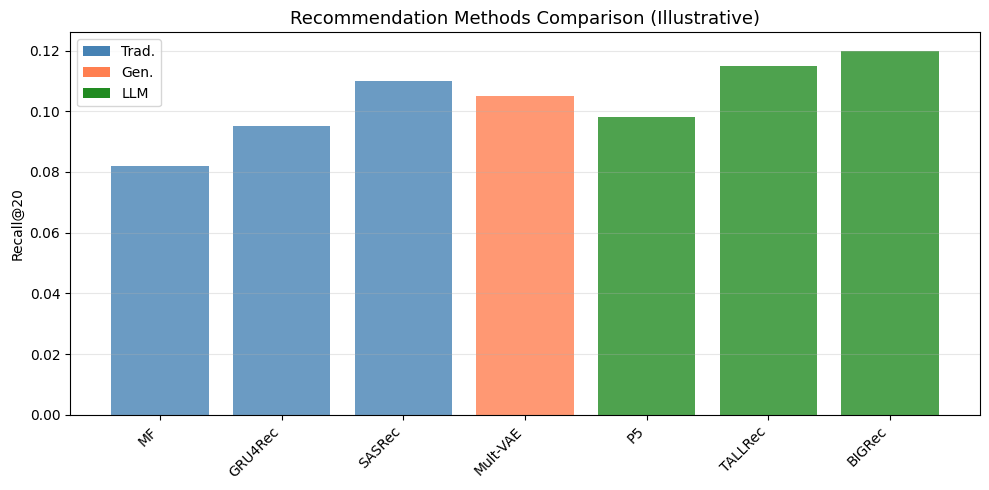

In [10]:
# Simulate performance comparison
# (In practice, these would be real benchmark results)
methods = ['MF', 'GRU4Rec', 'SASRec', 'Mult-VAE', 'P5', 'TALLRec', 'BIGRec']
recall_20 = [0.082, 0.095, 0.110, 0.105, 0.098, 0.115, 0.120]
ndcg_20 = [0.045, 0.055, 0.068, 0.062, 0.058, 0.072, 0.078]
model_types = ['Trad.', 'Trad.', 'Trad.', 'Gen.', 'LLM', 'LLM', 'LLM']

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
colors = {'Trad.': 'steelblue', 'Gen.': 'coral', 'LLM': 'forestgreen'}
x_pos = np.arange(len(methods))
bars = ax.bar(x_pos, recall_20, color=[colors[t] for t in model_types], alpha=0.8)

ax.set_xticks(x_pos)
ax.set_xticklabels(methods, rotation=45, ha='right')
ax.set_ylabel('Recall@20')
ax.set_title('Recommendation Methods Comparison (Illustrative)', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[t], label=t) for t in ['Trad.', 'Gen.', 'LLM']]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

## Exercises

### 🏋️ Exercise 1: Build a Multi-Task Prompt System

Create a unified prompt system that handles rating prediction, sequential rec, and explanation in a single template.

In [11]:
# TODO: Implement a multi-task prompt system
class UnifiedPrompt:
    """
    TODO: Create a unified prompt template that:
    1. Takes a task_type parameter: 'rating', 'sequential', 'explanation'
    2. Includes a task prefix to tell the model what to do
    3. Formats user history appropriately for each task
    4. Returns both the prompt and expected output format
    """
    
    def __init__(self, item_catalog):
        self.catalog = item_catalog
    
    def generate_prompt(self, task_type, user_history, **kwargs):
        # TODO: Implement
        pass

# TODO: Test with all three task types

### 🏋️ Exercise 2: Implement Semantic ID Generation with Improved Quantization

Improve the RQ-VAE with better codebook learning and analyze ID quality.

In [12]:
# TODO: Improve RQ-VAE
# 1. Add EMA codebook update (instead of gradient-based)
# 2. Add codebook diversity loss to prevent unused codes
# 3. Measure: what percentage of codes are used?
# 4. Measure: do items of the same genre share first code?
# 5. Visualize the codebook usage histogram

### 🏋️ Exercise 3: Compare Prompt Strategies

Using our small transformer model, compare different input formatting strategies.

In [13]:
# TODO: Compare input strategies for the SimpleRecTransformer
# Strategy A: Chronological order (oldest first)
# Strategy B: Reverse chronological (newest first)
# Strategy C: Random order
# Strategy D: Sorted by genre similarity
#
# For each strategy:
# 1. Re-prepare training data with the new ordering
# 2. Train the model
# 3. Evaluate Hit Rate@1 and Hit Rate@5
# 4. Plot comparison

## Summary

| Model | Key Innovation | Year | Approach |
|-------|---------------|------|----------|
| **P5** | Unified text-to-text rec | 2022 | T5-based multi-task |
| **GPT4Rec** | Generative sequential rec | 2023 | GPT for next-item |
| **TALLRec** | LoRA tuning for rec | 2023 | LLaMA + LoRA |
| **BIGRec** | LLM generates item titles | 2024 | Generative + grounding |
| **LC-Rec** | RQ-VAE semantic IDs | 2024 | Semantic tokenization |
| **LETTER** | LLM-enhanced text features | 2024 | Text enrichment |

**Key Takeaways:**
1. LLMs enable a paradigm shift from discriminative to generative recommendation
2. Prompt design is critical — it determines what knowledge the LLM can leverage
3. LoRA makes LLM fine-tuning practical for recommendation
4. Semantic IDs bridge the gap between continuous embeddings and discrete tokens
5. Hallucination is a key challenge requiring grounding mechanisms